In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

netflix_results = pd.read_csv(
    "../outputs/netflix_results.csv"
)

apple_results = pd.read_csv(
    "../outputs/apple_results.csv"
)

In [2]:
netflix_plot = netflix_results.dropna(
    subset=["Validation Inflation (%)"]
)

apple_plot = apple_results.dropna(
    subset=["Validation Inflation (%)"]
)

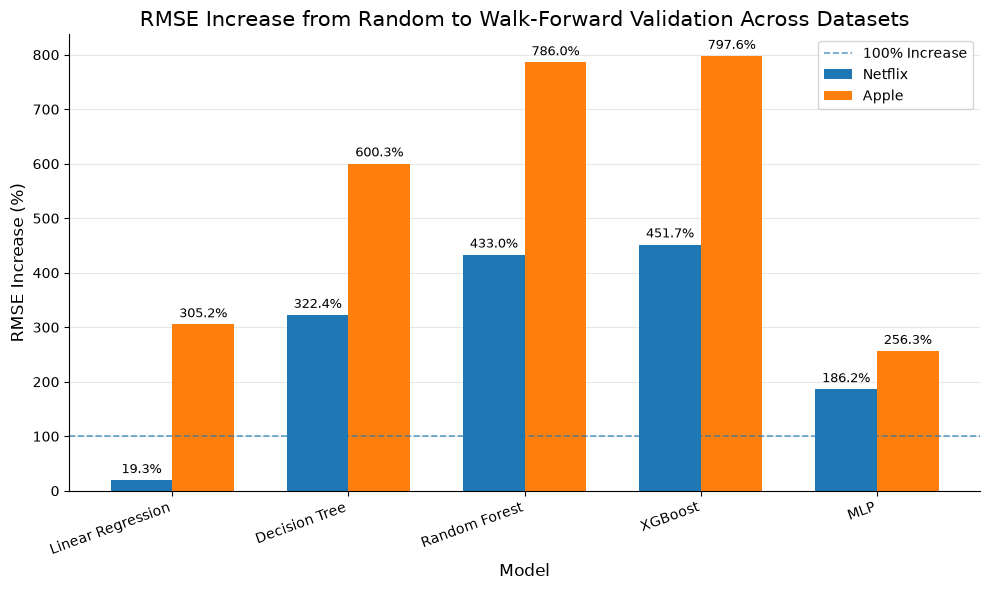

In [3]:
models = netflix_plot["Model"].tolist()

netflix_inflation = netflix_plot[
    "Validation Inflation (%)"
].to_numpy()

apple_inflation = apple_plot[
    "Validation Inflation (%)"
].to_numpy()

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(
    x - width / 2,
    netflix_inflation,
    width,
    label="Netflix"
)

bars2 = ax.bar(
    x + width / 2,
    apple_inflation,
    width,
    label="Apple"
)

ax.set_title(
    "RMSE Increase from Random to Walk-Forward Validation Across Datasets",
    fontsize=15
)

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("RMSE Increase (%)", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(
    models,
    rotation=20,
    ha="right"
)

ax.axhline(
    y=100,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    label="100% Increase"
)

ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.bar_label(
    bars1,
    labels=[f"{v:.1f}%" for v in netflix_inflation],
    padding=3,
    fontsize=9
)

ax.bar_label(
    bars2,
    labels=[f"{v:.1f}%" for v in apple_inflation],
    padding=3,
    fontsize=9
)

ax.legend()

plt.tight_layout()
plt.show()

###### Percentage increase in RMSE from random train-test splitting to walk-forward validation for Netflix and Apple. Walk-forward RMSE was higher for every model-dataset combination evaluated under both strategies, although the magnitude of the increase varied substantially across models and datasets.

###### The random-to-walk-forward increase in RMSE was positive for every model evaluated across both datasets, indicating consistently more optimistic error estimates under random splitting. However, the magnitude of this difference varied substantially across both models and datasets. Tree-based methods exhibited particularly large increases on both Netflix and Apple, while Linear Regression showed minimal deterioration on Netflix but substantial deterioration on Apple. These results suggest that sensitivity to validation methodology cannot be attributed solely to model architecture and may depend on characteristics of the underlying financial time series.